# Loan Default Prediction

In [1]:
%load_ext autoreload
%autoreload 2

from scripts.utilities import *
from scripts.features import *

## 1. Load and Process Data

In [2]:
# Load raw data
consumer_df, account_df, transaction_df = get_data()

# Filter consumers with no transaction or balance information
consumer_df, account_df, transaction_df = filter_unknown(consumer_df, account_df, transaction_df)

Data successfully loaded and processed.


In [3]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    outflow_over_time_fix,
    balance_over_time
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 8
- Unchanged feature creation functions: 8 (using cached results)

No feature creation functions need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats
- Using cached result for outflow_over_time_fix
- Using cached result for balance_over_time

Total Created Features:  266


## 2 Split Data

In [4]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 7591
No validation set created.
Test set size: 2531


## 3. All Model Performances

In [5]:
summary_table = evaluate_feature_model_combinations(train_df, test_df, all_feature_columns)

Evaluating: Feature Selection = all_features, Model = xgboost
Evaluating: Feature Selection = all_features, Model = gradient_boosting
Evaluating: Feature Selection = all_features, Model = random_forest
Evaluating: Feature Selection = all_features, Model = logistic


c:\Users\bdion\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluating: Feature Selection = mutual_info, Model = xgboost
Evaluating: Feature Selection = mutual_info, Model = gradient_boosting
Evaluating: Feature Selection = mutual_info, Model = random_forest
Evaluating: Feature Selection = mutual_info, Model = logistic
Evaluating: Feature Selection = random_forest, Model = xgboost
Evaluating: Feature Selection = random_forest, Model = gradient_boosting
Evaluating: Feature Selection = random_forest, Model = random_forest
Evaluating: Feature Selection = random_forest, Model = logistic
Evaluating: Feature Selection = xgboost, Model = xgboost
Evaluating: Feature Selection = xgboost, Model = gradient_boosting
Evaluating: Feature Selection = xgboost, Model = random_forest
Evaluating: Feature Selection = xgboost, Model = logistic


In [6]:
summary_table

,Feature Selection,Model,Test Accuracy,Test Balanced Accuracy,Test ROC AUC
0,all_features,xgboost,0.78,0.72,0.80
1,all_features,gradient_boosting,0.92,0.52,0.81
2,all_features,random_forest,0.92,0.52,0.78
3,all_features,logistic,0.69,0.69,0.73
4,mutual_info,xgboost,0.75,0.71,0.79
5,mutual_info,gradient_boosting,0.92,0.53,0.80
6,mutual_info,random_forest,0.92,0.51,0.78
7,mutual_info,logistic,0.64,0.67,0.73
8,random_forest,xgboost,0.76,0.72,0.80
9,random_forest,gradient_boosting,0.92,0.54,0.81


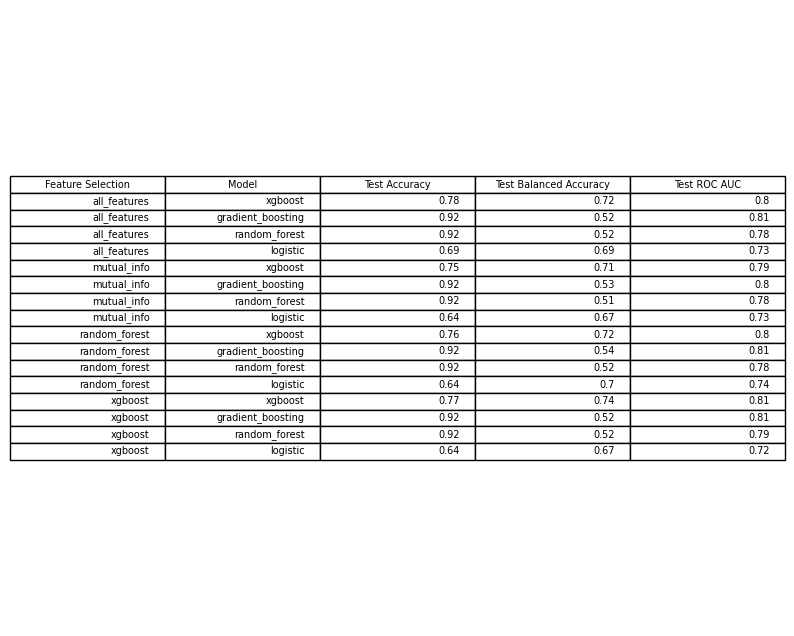

In [7]:
# Set up the matplotlib figure and axis
fig, ax = plt.subplots(figsize=(len(summary_table.columns) * 2, len(summary_table) * 0.5))
ax.axis('tight')
ax.axis('off')

# Create the table plot from the DataFrame
table = ax.table(cellText=summary_table.values, colLabels=summary_table.columns, loc='center')
 
# Save the figure as an image file
plt.show()

## 4. Individual Model Training

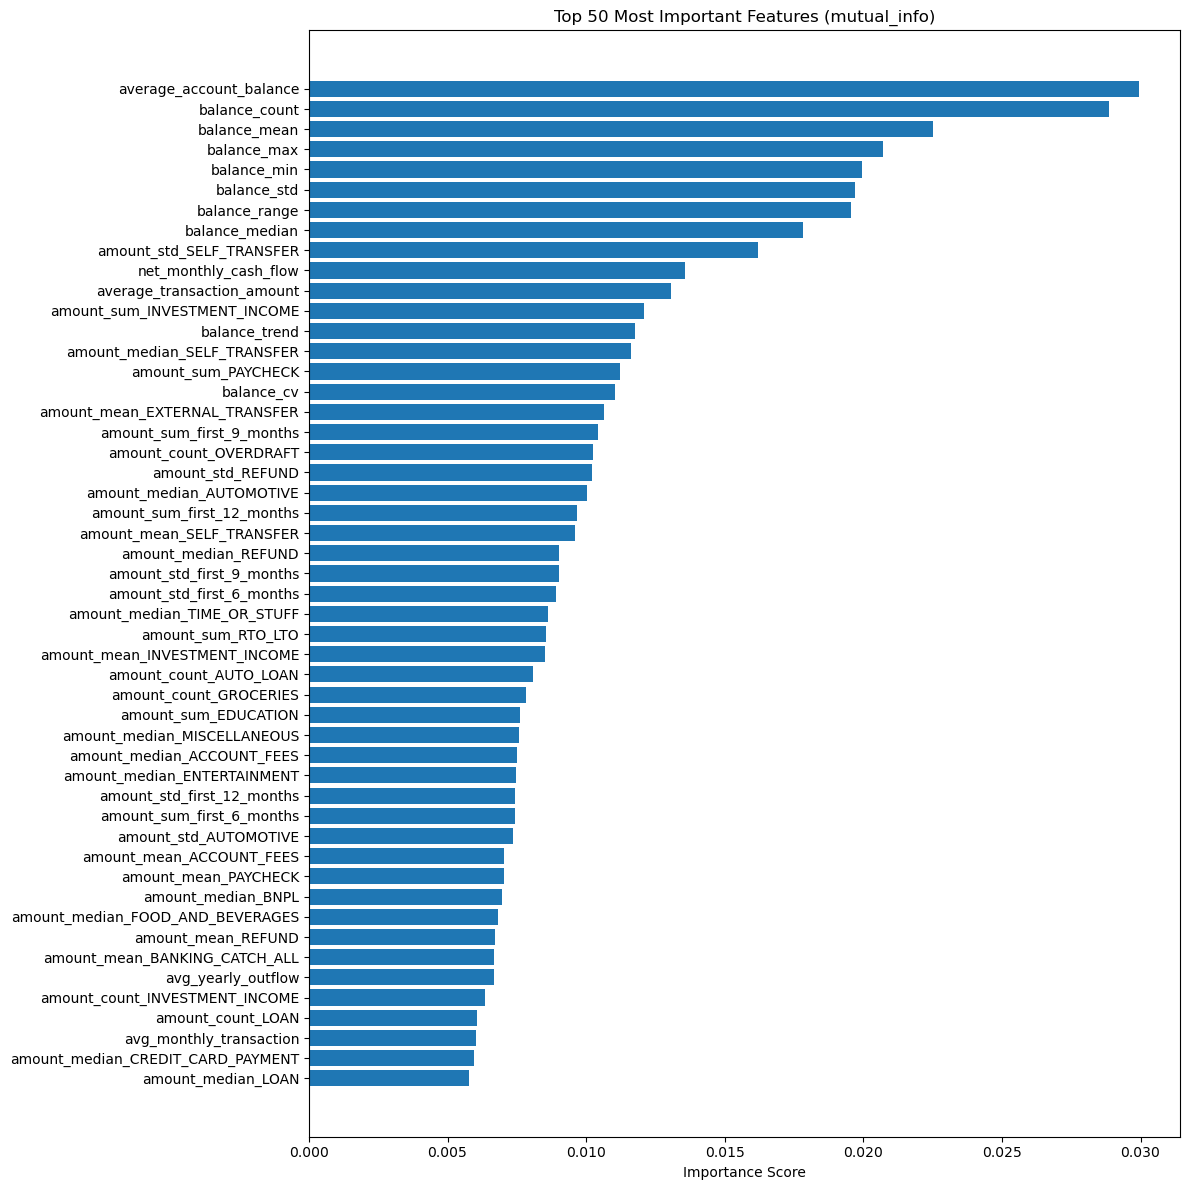

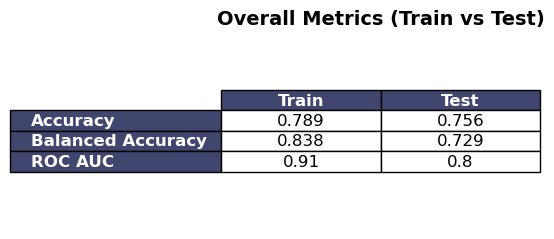


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.987736  0.778307  0.870603  6933.000000  0.966176  0.761393  0.851647  2326.000000
1.0           0.277726  0.898176  0.424264   658.000000  0.204871  0.697561  0.316722   205.000000
accuracy      0.788697  0.788697  0.788697     0.788697  0.756223  0.756223  0.756223     0.756223
macro avg     0.632731  0.838241  0.647434  7591.000000  0.585523  0.729477  0.584185  2531.000000
weighted avg  0.926191  0.788697  0.831914  7591.000000  0.904513  0.756223  0.808320  2531.000000


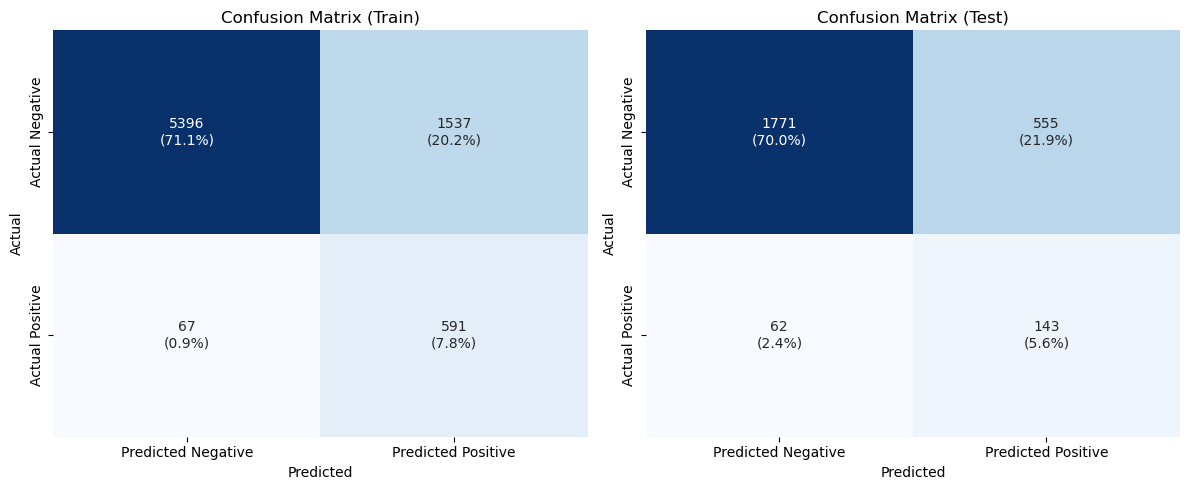

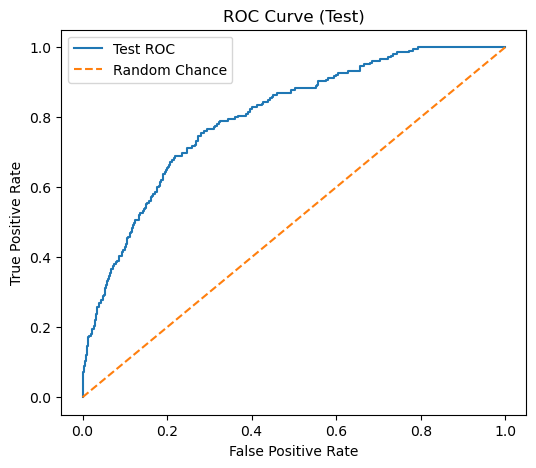

In [8]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=50)

# Initialize and train model with all features
X_train, X_train_scaled, model, scaler = train_model(train_df, feature_columns, "xgboost")
X_test, X_test_scaled, y_test, y_pred_test, results = predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)

## 5. SHAP

- Most impactful features for the model overall (according to SHAP):

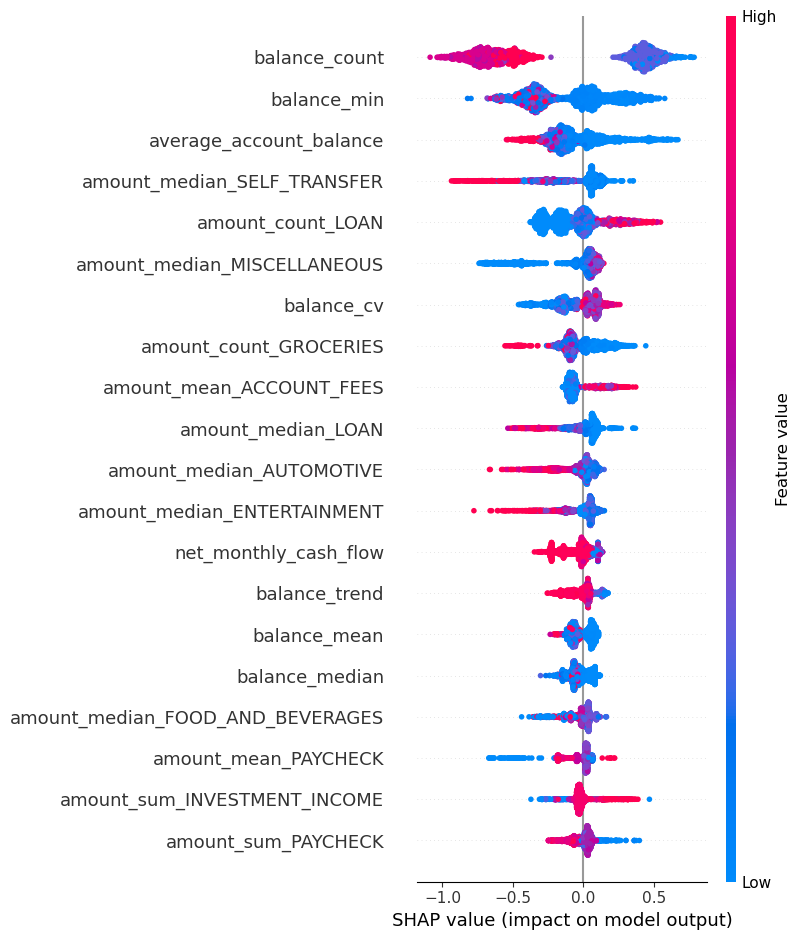

In [9]:
scaled_feats, explainer, shap_values = shap_plots(model, X_test, X_test_scaled)

- Waterfall plot for an individual person:
    - Person here was predicted as not defaulting

In [13]:
y_pred_test[0]

0

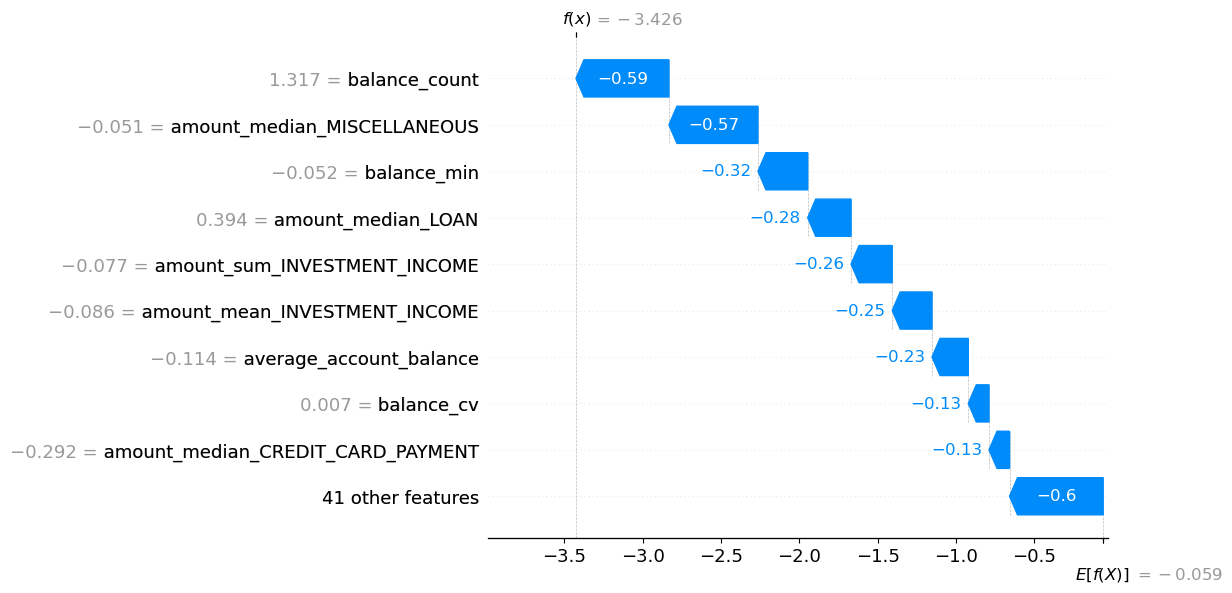

In [10]:
shap.plots.waterfall(shap_values[0])

- Reason codes for default:

In [11]:
scaled_feats['y_true'] = y_test.values
scaled_feats['y_pred'] = y_pred_test

shap_values = explainer(scaled_feats.drop(columns=['y_true', 'y_pred']))

shap_df = pd.DataFrame(shap_values.values, columns=scaled_feats.drop(columns=['y_true', 'y_pred']).columns)

mask = scaled_feats['y_pred'] == 1
shap_df_pred_default = shap_df[mask].reset_index(drop=True)

def get_top_feature_names(shap_row, feature_names, top_n=3):
    top_indices = np.argsort(shap_row)[::-1][:top_n]  
    return [feature_names[i] for i in top_indices]  

top_features_pred_default = shap_df_pred_default.apply(
    lambda row: get_top_feature_names(row, shap_df.columns), axis=1
)

top_features_df = pd.DataFrame(top_features_pred_default.tolist(), columns=['Feature_1', 'Feature_2', 'Feature_3'])
top_features_df

,Feature_1,Feature_2,Feature_3
0,balance_count,balance_min,amount_median_MISCELLANEOUS
1,balance_count,average_account_balance,balance_min
2,balance_count,balance_min,amount_sum_first_9_months
3,amount_count_OVERDRAFT,amount_median_SELF_TRANSFER,amount_median_BNPL
4,balance_count,amount_sum_INVESTMENT_INCOME,amount_count_LOAN
...,...,...,...
693,balance_count,amount_median_LOAN,average_account_balance
694,balance_count,balance_min,amount_count_GROCERIES
695,balance_count,amount_mean_ACCOUNT_FEES,amount_median_MISCELLANEOUS
696,amount_mean_SELF_TRANSFER,amount_count_LOAN,average_account_balance


In [12]:
top_features_pred_default.explode().value_counts()

balance_count                       615
balance_min                         395
average_account_balance             213
amount_mean_ACCOUNT_FEES            127
amount_count_LOAN                   120
amount_count_GROCERIES              118
amount_sum_INVESTMENT_INCOME         88
amount_median_MISCELLANEOUS          54
amount_median_AUTOMOTIVE             50
amount_std_REFUND                    45
amount_count_OVERDRAFT               42
amount_median_SELF_TRANSFER          39
amount_median_BNPL                   26
balance_cv                           20
amount_median_LOAN                   17
balance_median                       15
amount_mean_SELF_TRANSFER            12
balance_trend                        11
amount_sum_PAYCHECK                  11
balance_mean                         10
amount_median_FOOD_AND_BEVERAGES     10
amount_mean_REFUND                    9
amount_std_first_6_months             8
amount_median_ENTERTAINMENT           7
amount_mean_BANKING_CATCH_ALL         7
